In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import glob
import datetime
from pyproj import Proj
from scipy import interpolate
import matplotlib.pyplot as plt

In [2]:
def to_binary_string(num):
    """
    Turns an input integer into a binary string.

    Args:
    num (int): Number to convert to a binary string.
               Gets converted to an integer if it is not already

    Returns:
    (str): String of the binary value of the input integer
    """
    if np.isnan(num):
        return np.nan
    else:
        return f'{int(num):b}'

In [3]:
"""
Export coordinates for each urban area
KEY: [utm zone, T/F for Northern Hemisphere]
"""
proj_zone = {
    'DMV':[18, True], 'NYC':[18, True], 'Phoenix':[12, True], 'Miami':[17, True], 'Chicago':[16, True], 'Denver':[13, True],
    'Seattle':[10, True], 'San_Francisco':[10, True], 'Los_Angeles':[11, True], 'Atlanta':[16, True], 'Toronto':[17, True],
    'Mexico_City':[14, True], 'Las_Vegas':[11, True], 'Salt_Lake_City':[12, True], 'Dallas':[14, True], 'Houston':[15, True],
    'New_Orleans':[15, True], 'St_Louis':[15, True], 'Minneapolis':[15, True], 'Jacksonville':[17, True], 'Charlotte':[17, True],
    'Philadelphia':[18, True], 'San_Diego':[11, True], 'San_Juan':[19, True], 'Montreal':[18, True], 'Guadalajara':[13, True],
    'Monterrey':[14, True], 'Cancun':[16, True], 'Billings':[12, True], 'Guatemala_City':[15, True], 'San_Jose':[16, True],
    'Havana':[17, True], 'Santo_Domingo':[19, True], 'Tegucigalpa':[16, True], 'Managua':[16, True], 'Panama_City':[17, True],
    'Bogota':[18, True], 'Lima':[18, False], 'Quito':[17, True], 'Santiago':[19, False], 'Buenos_Aires':[21, False],
    'Sao_Paulo':[23, False], 'Manaus':[20, False], 'Punta_Arenas':[19, False],
    'La_Paz':[19, False], 'Montevideo':[21, False], 'Brasilia':[22, False], 'Caracas':[19, True]
}

In [4]:
# Creates a sorted list of the city names
cities = sorted(list(proj_zone.keys()))

In [5]:
# Dictionary for full city name strings
city_str_dict = {
    'Atlanta': 'Atlanta, Georgia, USA',
    'Billings': 'Billings, Montana, USA',
    'Bogota': 'Bogota, Colombia',
    'Brasilia': 'Brasilia, Brazil',
    'Buenos_Aires': 'Buenos Aires, Argentina',
    'Cancun': 'Cancun, Mexico',
    'Caracas': 'Caracas, Venezuela',
    'Charlotte': 'Charlotte, North Carolina, USA',
    'Chicago': 'Chicago, Illinois, USA',
    'Dallas': 'Dallas, Texas, USA and Fort Worth, Texas, USA',
    'Denver': 'Denver, Colorado, USA',
    'Guadalajara': 'Guadalajara, Mexico',
    'Guatemala_City': 'Guatemala City, Guatemala',
    'Havana': 'Havana, Cuba',
    'Houston': 'Houston, Texas, USA',
    'Jacksonville': 'Jacksonville, Florida, USA',
    'La_Paz': 'La Paz, Bolivia',
    'Las_Vegas': 'Las Vegas, Nevada, USA',
    'Lima': 'Lima, Peru',
    'Los_Angeles': 'Los Angeles, California, USA',
    'Managua': 'Managua, Nicaragua',
    'Manaus': 'Manaus, Brazil',
    'Mexico_City': 'Mexico City, Mexico',
    'Miami': 'Miami, Florida, USA',
    'Minneapolis': 'Minneapolis, Minnesota, USA',
    'Monterrey': 'Monterrey, Mexico',
    'Montevideo': 'Montevideo, Uruguay',
    'Montreal': 'Montreal, Quebec, Canada',
    'New_Orleans': 'New Orleans, Louisiana, USA',
    'NYC': 'New York City, New York, USA',
    'Panama_City': 'Panama City, Panama',
    'Philadelphia': 'Philadelphia, Pennsylvania, USA',
    'Phoenix': 'Phoenix, Arizona, USA',
    'Punta_Arenas': 'Punta Arenas, Chile',
    'Quito': 'Quito, Ecuador',
    'Salt_Lake_City': 'Salt Lake City, Utah, USA',
    'San_Diego': 'San Diego, California, USA and Tijuana, Mexico',
    'San_Francisco': 'San Francisco, California, USA and San Jose, California, USA',
    'San_Jose': 'San Jose, Costa Rica',
    'San_Juan': 'San Juan, Puerto Rico',
    'Santiago': 'Santiago, Chile',
    'Santo_Domingo': 'Santo Domingo, Dominican Republic',
    'Sao_Paulo': 'Sao Paulo, Brazil',
    'Seattle': 'Seattle, Washington, USA',
    'St_Louis': 'St Louis, Missouri, USA',
    'Tegucigalpa': 'Tegucigalpa, Honduras',
    'Toronto': 'Toronto, Ontario, Canada',
    'DMV': 'Washington, DC, USA and Baltimore, Maryland, USA'
}

In [6]:
city_ICAO_codes = {
    'Atlanta': 'KATL',
    'Billings': 'KBIL',
    'Bogota': 'SKBO',
    'Brasilia': 'SBBR',
    'Buenos_Aires': 'SAEZ',
    'Cancun': 'MMUN',
    'Caracas': 'SVMI',
    'Charlotte': 'KCLT',
    'Chicago': 'KORD',
    'Dallas': 'KDFW',
    'Denver': 'KDEN',
    'Guadalajara': 'MMGL',
    'Guatemala_City': 'MGGT',
    'Havana': 'MUHA',
    'Houston': 'KIAH',
    'Jacksonville': 'KJAX',
    'La_Paz': 'SLLP',
    'Las_Vegas': 'KLAS',
    'Lima': 'SPJC',
    'Los_Angeles': 'KLAX',
    'Managua': 'MNMG',
    'Manaus': 'SBEG',
    'Mexico_City': 'MMMX',
    'Miami': 'KMIA',
    'Minneapolis': 'KMSP',
    'Monterrey': 'MMMY',
    'Montevideo': 'SUMU',
    'Montreal': 'CYUL',
    'New_Orleans': 'KMSY',
    'NYC': 'KJFK',
    'Panama_City': 'MPTO',
    'Philadelphia': 'KPHL',
    'Phoenix': 'KPHX',
    'Punta_Arenas': 'SCCI',
    'Quito': 'SEQM',
    'Salt_Lake_City': 'KSLC',
    'San_Diego': 'KSAN',
    'San_Francisco': 'KSFO',
    'San_Jose': 'MROC',
    'San_Juan': 'TJSJ',
    'Santiago': 'SCEL',
    'Santo_Domingo': 'MDSD',
    'Sao_Paulo': 'SBGR',
    'Seattle': 'KSEA',
    'St_Louis': 'KSTL',
    'Tegucigalpa': 'MHTG',
    'Toronto': 'CYYZ',
    'DMV': 'KBWI'
}

In [7]:
city = 'Bogota'
city_zone = proj_zone[city]
city_zone

[18, True]

In [8]:
# Define UTM18N projection (WGS84 datum)
if city_zone[1]:
    crs_prefix = '326'
else:
    crs_prefix = '327'
proj_code = f'EPSG:{crs_prefix}{city_zone[0]}'
utm_proj = Proj(projparams=proj_code)

In [9]:
tmp_dataset_root = '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp'
dataset_root = '/glade/derecho/scratch/jstarfeldt/uhminicubes'

In [10]:
"""
Returns an integer as a str, adding a zero in front if it is a single digit.

Attributes:
    num (int): Integer to turn into a string.
"""
def stringify(num):
    if num >= 0 and num < 10:
        return f'0{num}'
    else:
        return str(num)

## Produce latlons

In [11]:
def stacked_to_latlon(pt):
    """
    Reprojects a point in UTM coordinates to
    latitude and longitude coordinates.

    Args:
    pt (tuple-like): Tuple with format (x coord, y coord) to reproject

    Returns:
    (tuple): Tuple with format (longitude, latitude)
    """
    return utm_proj(pt[0], pt[1], inverse=True)

In [12]:
def create_city_latlons(city):
    """
    Calculates the latitude and longitude coordinates for the UTM coordinates
    of both the Landsat/Sentinel-1 files and GOES/MW LST files for a given
    city, and saves them as xarray DataArrays.

    Args:
    city (str): City from the 'cities' list
    """
    city_dir = f'{tmp_dataset_root}/{city}'
    Landsat_file_list = glob.glob(f'{city_dir}/Landsat/*')
    GOES_file_list = glob.glob(f'{city_dir}/GOES_2022_1/*')

    # Produce Landsat latlons
    ds = rxr.open_rasterio(Landsat_file_list[0])[:, :3000, :3000]
    ds = ds.reindex(y=ds.y[::-1]) # Invert y-axis so that values are increasing instead of decreasing with index
    geotiff_ds = ds.to_dataset('band')
    y, x = np.meshgrid(geotiff_ds['y'], geotiff_ds['x'])
    utm_coords = np.stack((x,y)).T.reshape(-1, 2)

    latlon_pts = np.array(list(map(stacked_to_latlon, utm_coords)))
    latlon_pts = latlon_pts.reshape((3000, 3000, 2))

    latlon_ds = geotiff_ds
    #latlon_ds['latlon'] = (('y', 'x', 'coords'), latlon_pts)
    latlon_ds['latitude'] = (('y', 'x'), latlon_pts[:, :, 1])
    latlon_ds['longitude'] = (('y', 'x'), latlon_pts[:, :, 0])
    latlon_ds = latlon_ds.drop_vars(list(range(1, 14)))

    del latlon_ds.attrs['long_name']
    del latlon_ds.attrs['scale_factor']
    del latlon_ds.attrs['add_offset']
    latlon_ds.attrs['title'] = f'Latitude and Longitude coordinates of high-resolution grid for {city_str_dict[city]}'
    latlon_ds.attrs['institution'] = 'University of Maryland, College Park'

    latlon_ds['y'].attrs['standard_name'] = 'projection_y_coordinate'
    latlon_ds['y'].attrs['long_name'] = 'UTM Northing'
    latlon_ds['y'].attrs['units'] = 'm'

    latlon_ds['x'].attrs['standard_name'] = 'projection_x_coordinate'
    latlon_ds['x'].attrs['long_name'] = 'UTM Easting'
    latlon_ds['x'].attrs['units'] = 'm'

    latlon_ds['latitude'].attrs['standard_name'] = 'latitude'
    latlon_ds['latitude'].attrs['units'] = 'degree'
    latlon_ds['latitude'].attrs['valid_min'] = '-90'
    latlon_ds['latitude'].attrs['valid_max'] = '90'

    latlon_ds['longitude'].attrs['standard_name'] = 'longitude'
    latlon_ds['longitude'].attrs['units'] = 'degree'
    latlon_ds['longitude'].attrs['valid_min'] = '-180'
    latlon_ds['longitude'].attrs['valid_max'] = '180'

    latlon_ds.to_netcdf(f'/glade/derecho/scratch/jstarfeldt/uhminicubes/hresgrid/latlon/hresgrid_{city_ICAO_codes[city]}_latlon.nc')

    # Produce GOES latlons
    ds = rxr.open_rasterio(GOES_file_list[0])
    ds = ds.reindex(y=ds.y[::-1]) # Invert y-axis so that values are increasing instead of decreasing with index
    geotiff_ds = ds.to_dataset('band')
    y, x = np.meshgrid(ds['y'], ds['x'])
    utm_coords = np.stack((x, y)).T.reshape(-1, 2)

    latlon_pts = np.array(list(map(stacked_to_latlon, utm_coords)))
    latlon_pts = latlon_pts.reshape((45, 45, 2))

    latlon_ds = geotiff_ds
    #latlon_ds['latlon'] = (('y', 'x', 'coords'), latlon_pts)
    latlon_ds['latitude'] = (('y', 'x'), latlon_pts[:, :, 1])
    latlon_ds['longitude'] = (('y', 'x'), latlon_pts[:, :, 0])
    latlon_ds = latlon_ds.drop_vars(list(range(1, 5)))

    del latlon_ds.attrs['scale_factor']
    del latlon_ds.attrs['add_offset']
    del latlon_ds.attrs['TIFFTAG_XRESOLUTION']
    del latlon_ds.attrs['TIFFTAG_YRESOLUTION']
    del latlon_ds.attrs['TIFFTAG_RESOLUTIONUNIT']
    del latlon_ds.attrs['_FillValue']
    latlon_ds.attrs['title'] = f'Latitude and Longitude coordinates of low-resolution grid for {city_str_dict[city]}'
    latlon_ds.attrs['institution'] = 'University of Maryland, College Park'

    latlon_ds['y'].attrs['standard_name'] = 'projection_y_coordinate'
    latlon_ds['y'].attrs['long_name'] = 'UTM Northing'
    latlon_ds['y'].attrs['units'] = 'm'

    latlon_ds['x'].attrs['standard_name'] = 'projection_x_coordinate'
    latlon_ds['x'].attrs['long_name'] = 'UTM Easting'
    latlon_ds['x'].attrs['units'] = 'm'

    latlon_ds['latitude'].attrs['standard_name'] = 'latitude'
    latlon_ds['latitude'].attrs['units'] = 'degree'
    latlon_ds['latitude'].attrs['valid_min'] = '-90'
    latlon_ds['latitude'].attrs['valid_max'] = '90'

    latlon_ds['longitude'].attrs['standard_name'] = 'longitude'
    latlon_ds['longitude'].attrs['units'] = 'degree'
    latlon_ds['longitude'].attrs['valid_min'] = '-180'
    latlon_ds['longitude'].attrs['valid_max'] = '180'


    latlon_ds.to_netcdf(f'/glade/derecho/scratch/jstarfeldt/uhminicubes/lresgrid/latlon/lresgrid_{city_ICAO_codes[city]}_latlon.nc')

In [13]:
for city in cities:
    city_zone = proj_zone[city]
    if city_zone[1]:
        crs_prefix = '326'
    else:
        crs_prefix = '327'
    proj_code = f'EPSG:{crs_prefix}{city_zone[0]}'
    utm_proj = Proj(projparams=proj_code)
    create_city_latlons(city)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

# Sample Code

## Landsat

In [17]:
city = 'Bogota'

# Loads the Landsat file times for the current city
times_Landsat = pd.read_csv(f'{tmp_dataset_root}/Landsat_times/Landsat_times_{city}.csv').value
times_Landsat[:5]

0    1.641568e+12
1    1.642951e+12
2    1.645716e+12
3    1.647098e+12
4    1.648480e+12
Name: value, dtype: float64

In [18]:
# Gets the list of unprocessed Landsat/Sentinel-1 files for the current city
Landsat_root = f'{tmp_dataset_root}/{city}/Landsat'
Landsat_tif_list = glob.glob(Landsat_root+'/Landsat8*.tif')
Landsat_tif_list[0]

'/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Bogota/Landsat/Landsat8_Sentinel_image_Bogota_202301261513.tif'

In [19]:
def sort_func_Landsat(s):
    """
    Gets the datetime from a Landsat/Sentinel-1 file string.
    Used to sort the list of files in a directory.

    Args:
    s (str): Full file location string of a Landsat/Sentinel-1 file

    Returns:
    (int): File datetime as an integer
    """
    return int(s.split(f'{city}_')[1].split('.tif')[0])

In [20]:
# Sorts the list of Landsat/Sentinel-1 files
Landsat_tif_list = sorted(Landsat_tif_list, key=sort_func_Landsat)
Landsat_tif_list[0]

'/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Bogota/Landsat/Landsat8_Sentinel_image_Bogota_202301261513.tif'

In [21]:
# Loads a single file from the file list to process
dsLS = rxr.open_rasterio(Landsat_tif_list[0])[:, :3000, :3000]
dsLS = dsLS.reindex(y=dsLS.y[::-1]) # Invert y-axis so that values are increasing instead of decreasing with index
geotiff_dsLS = dsLS.to_dataset('band')

In [22]:
geotiff_dsLS

<xarray.Dataset> Size: 936MB
Dimensions:      (y: 3000, x: 3000)
Coordinates:
  * x            (x) float64 24kB 5.464e+05 5.465e+05 ... 6.364e+05 6.364e+05
  * y            (y) float64 24kB 4.718e+05 4.718e+05 ... 5.617e+05 5.617e+05
    spatial_ref  int64 8B 0
Data variables: (12/13)
    1            (y, x) float64 72MB ...
    2            (y, x) float64 72MB ...
    3            (y, x) float64 72MB ...
    4            (y, x) float64 72MB ...
    5            (y, x) float64 72MB ...
    6            (y, x) float64 72MB ...
    ...           ...
    8            (y, x) float64 72MB ...
    9            (y, x) float64 72MB ...
    10           (y, x) float64 72MB ...
    11           (y, x) float64 72MB ...
    12           (y, x) float64 72MB ...
    13           (y, x) float64 72MB ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'S...

In [23]:
# Gets the UTM coordinates of each point in the coordinate grid
y, x = np.meshgrid(geotiff_dsLS['y'], geotiff_dsLS['x'])
utm_coords = np.stack((x,y)).T.reshape(-1,2)
utm_coords

array([[546435., 471765.],
       [546465., 471765.],
       [546495., 471765.],
       ...,
       [636345., 561735.],
       [636375., 561735.],
       [636405., 561735.]], shape=(9000000, 2))

In [24]:
# Converts the UTM coordinates to latitude and longitude coordinates
latlon_pts = np.array(list(map(stacked_to_latlon, utm_coords)))
latlon_pts = latlon_pts.reshape((3000, 3000, 2))
latlon_pts

array([[[-80.58155138,   4.26801259],
        [-80.58128104,   4.26801244],
        [-80.5810107 ,   4.26801229],
        ...,
        [-79.77141241,   4.26714263],
        [-79.77114213,   4.26714219],
        [-79.77087185,   4.26714176]],

       [[-80.58155123,   4.26828399],
        [-80.58128089,   4.26828384],
        [-80.58101055,   4.26828369],
        ...,
        [-79.77141198,   4.26741397],
        [-79.7711417 ,   4.26741353],
        [-79.77087141,   4.2674131 ]],

       [[-80.58155109,   4.26855538],
        [-80.58128075,   4.26855523],
        [-80.58101041,   4.26855509],
        ...,
        [-79.77141155,   4.26768531],
        [-79.77114127,   4.26768488],
        [-79.77087098,   4.26768444]],

       ...,

       [[-80.58106858,   5.08138031],
        [-80.58079793,   5.08138014],
        [-80.58052727,   5.08137996],
        ...,
        [-79.76999526,   5.08034379],
        [-79.76972467,   5.08034327],
        [-79.76945407,   5.08034276]],

       [[-80.58

In [25]:
latlon_ds = geotiff_dsLS
latlon_ds['latlon'] = (('y', 'x', 'coords'), latlon_pts)
latlon_ds = latlon_ds.drop_vars(list(range(1, 14)))
latlon_ds

<xarray.Dataset> Size: 144MB
Dimensions:      (x: 3000, y: 3000, coords: 2)
Coordinates:
  * x            (x) float64 24kB 5.464e+05 5.465e+05 ... 6.364e+05 6.364e+05
  * y            (y) float64 24kB 4.718e+05 4.718e+05 ... 5.617e+05 5.617e+05
    spatial_ref  int64 8B 0
Dimensions without coordinates: coords
Data variables:
    latlon       (y, x, coords) float64 144MB -80.58 4.268 ... -79.77 5.081
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'S...

In [22]:
del latlon_ds.attrs['long_name']
del latlon_ds.attrs['scale_factor']
del latlon_ds.attrs['add_offset']
latlon_ds.attrs['title'] = f'Latitude and Longitude coordinates of Landsat and Sentinel-1 data for {city_str_dict[city]}'
latlon_ds.attrs['institution'] = 'University of Maryland, College Park'

latlon_ds['y'].attrs['standard_name'] = 'projection_y_coordinate'
latlon_ds['y'].attrs['long_name'] = 'UTM Northing'
latlon_ds['y'].attrs['units'] = 'm'

latlon_ds['x'].attrs['standard_name'] = 'projection_x_coordinate'
latlon_ds['x'].attrs['long_name'] = 'UTM Easting'
latlon_ds['x'].attrs['units'] = 'm'

latlon_ds['latlon'].attrs['long_name'] = 'latitude_longitude_coordinate_points'
latlon_ds['latlon'].attrs['units'] = 'degree'
latlon_ds['latlon'].attrs['valid_min'] = '-180'
latlon_ds['latlon'].attrs['valid_max'] = '180'

In [23]:
latlon_ds

<xarray.Dataset> Size: 144MB
Dimensions:      (x: 3000, y: 3000, coords: 2)
Coordinates:
  * x            (x) float64 24kB 5.464e+05 5.465e+05 ... 6.364e+05 6.364e+05
  * y            (y) float64 24kB 4.718e+05 4.718e+05 ... 5.617e+05 5.617e+05
    spatial_ref  int64 8B 0
Dimensions without coordinates: coords
Data variables:
    latlon       (y, x, coords) float64 144MB -74.58 4.268 ... -73.77 5.081
Attributes:
    AREA_OR_POINT:  Area
    title:          Latitude and Longitude coordinates of Landsat and Sentine...
    institution:    University of Maryland, College Park

In [24]:
# Names for Landsat/Sentinel tifs
geotiff_dsLS = geotiff_dsLS.rename({1:'Landsat_blue_sfc_reflectance', 2:'Landsat_green_sfc_reflectance',
                                    3:'Landsat_red_sfc_reflectance', 4:'Landsat_NIR_sfc_reflectance',
                                    5:'Landsat_SWIR1_sfc_reflectance', 6:'Landsat_SWIR2_sfc_reflectance',
                                    7:'Landsat_LST', 8:'Landsat_cloud_mask', 9:'Sentinel1_VV', 10:'Sentinel1_VH', 11:'Sentinel1_HH',
                                    12:'Sentinel1_HV', 13:'Sentinel1_incidence_angle'})

In [25]:
geotiff_dsLS['Landsat_cloud_mask'].values

array([[21824., 21824., 21824., ..., 21824., 21824., 21824.],
       [21824., 21824., 21824., ..., 21824., 21824., 21824.],
       [21824., 21824., 21824., ..., 21824., 21824., 21824.],
       ...,
       [21824., 21824., 21824., ..., 21824., 21824., 21824.],
       [21824., 21824., 21824., ..., 21824., 21824., 21824.],
       [21824., 21824., 21824., ..., 21824., 21824., 21824.]],
      shape=(3000, 3000))

In [26]:
# Turns the Landsat cloud mask into binary strings
binary_vectorized = np.vectorize(to_binary_string)
mask = binary_vectorized(geotiff_dsLS.Landsat_cloud_mask.values)

In [27]:
mask

array([['101010101000000', '101010101000000', '101010101000000', ...,
        '101010101000000', '101010101000000', '101010101000000'],
       ['101010101000000', '101010101000000', '101010101000000', ...,
        '101010101000000', '101010101000000', '101010101000000'],
       ['101010101000000', '101010101000000', '101010101000000', ...,
        '101010101000000', '101010101000000', '101010101000000'],
       ...,
       ['101010101000000', '101010101000000', '101010101000000', ...,
        '101010101000000', '101010101000000', '101010101000000'],
       ['101010101000000', '101010101000000', '101010101000000', ...,
        '101010101000000', '101010101000000', '101010101000000'],
       ['101010101000000', '101010101000000', '101010101000000', ...,
        '101010101000000', '101010101000000', '101010101000000']],
      shape=(3000, 3000), dtype='<U16')

In [28]:
# Sets the Landsat cloud mask variable as the array of binary strings
geotiff_dsLS['Landsat_cloud_mask'].values = mask

In [29]:
# Set a metadata reference key for the binary strings
geotiff_dsLS['Landsat_cloud_mask'].attrs['bitmask_key'] = \
"Bit 0: Fill\n\
Bit 1: Dilated Cloud\n\
Bit 2: Cirrus (high confidence)\n\
Bit 3: Cloud\n\
Bit 4: Cloud Shadow\n\
Bit 5: Snow\n\
Bit 6: Clear\n\t0: Cloud or Dilated Cloud bits are set\n\t1: Cloud and Dilated Cloud bits are not set\n\
Bit 7: Water\n\
Bits 8-9: Cloud Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High\n\
Bits 10-11: Cloud Shadow Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High\n\
Bits 12-13: Snow/Ice Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High\n\
Bits 14-15: Cirrus Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High"

In [30]:
geotiff_dsLS

<xarray.Dataset> Size: 2GB
Dimensions:                        (y: 3000, x: 3000, coords: 2)
Coordinates:
  * x                              (x) float64 24kB 5.464e+05 ... 6.364e+05
  * y                              (y) float64 24kB 4.718e+05 ... 5.617e+05
    spatial_ref                    int64 8B 0
Dimensions without coordinates: coords
Data variables: (12/14)
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_SWIR2_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB ...
    Sentinel1_VH                   (y, x) float64 72MB ...
    Sentinel1_HH                   (y, x) float64 72MB ...
    Sentinel1_HV                   (y, x) float64 72MB ...
    Sentinel1_incidence_angle      (y, x) float64 72MB ...
    latlon                         (y, x, coords) float64 144MB -74.58 ... 5.081
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'S...

In [31]:
# Assign a datetime coordinate to the file
dt = datetime.datetime.fromtimestamp(times_Landsat[0]/1000, datetime.UTC).strftime('%Y-%m-%dT%H:%M:%SZ')
geotiff_dsLS = geotiff_dsLS.assign_coords({'datetime':dt})

In [32]:
# Delete unnecessary metadata tag
del geotiff_dsLS.attrs['long_name']

In [33]:
geotiff_dsLS

<xarray.Dataset> Size: 2GB
Dimensions:                        (y: 3000, x: 3000, coords: 2)
Coordinates:
  * x                              (x) float64 24kB 5.464e+05 ... 6.364e+05
  * y                              (y) float64 24kB 4.718e+05 ... 5.617e+05
    spatial_ref                    int64 8B 0
    datetime                       <U20 80B '2022-01-07T15:12:59Z'
Dimensions without coordinates: coords
Data variables: (12/14)
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_SWIR2_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB ...
    Sentinel1_VH                   (y, x) float64 72MB ...
    Sentinel1_HH                   (y, x) float64 72MB ...
    Sentinel1_HV                   (y, x) float64 72MB ...
    Sentinel1_incidence_angle      (y, x) float64 72MB ...
    latlon                         (y, x, coords) float64 144MB -74.58 ... 5.081
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [34]:
# Sets anomalous Sentinel-1 values to NaN
for variable in ['Sentinel1_VV', 'Sentinel1_VH', 'Sentinel1_HH', 'Sentinel1_HV']:
    geotiff_dsLS[variable].values = np.where(geotiff_dsLS[variable].values > 1, np.nan, geotiff_dsLS[variable].values)
    
geotiff_dsLS['Sentinel1_incidence_angle'].values = np.where(geotiff_dsLS['Sentinel1_incidence_angle'].values < 0, np.nan,
                                                  geotiff_dsLS['Sentinel1_incidence_angle'].values)

In [35]:
geotiff_dsLS

<xarray.Dataset> Size: 2GB
Dimensions:                        (y: 3000, x: 3000, coords: 2)
Coordinates:
  * x                              (x) float64 24kB 5.464e+05 ... 6.364e+05
  * y                              (y) float64 24kB 4.718e+05 ... 5.617e+05
    spatial_ref                    int64 8B 0
    datetime                       <U20 80B '2022-01-07T15:12:59Z'
Dimensions without coordinates: coords
Data variables: (12/14)
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_SWIR2_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB -6.083 -8.685 ... -15.1
    Sentinel1_VH                   (y, x) float64 72MB -13.1 -13.79 ... -20.67
    Sentinel1_HH                   (y, x) float64 72MB nan nan nan ... nan nan
    Sentinel1_HV                   (y, x) float64 72MB nan nan nan ... nan nan
    Sentinel1_incidence_angle      (y, x) float64 72MB 39.18 39.18 ... 34.68
    latlon                         (y, x, coords) float64 144MB -74.58 ... 5.081
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [36]:
# Adds variable metadata
geotiff_dsLS['Landsat_blue_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
geotiff_dsLS['Landsat_blue_sfc_reflectance'].attrs['units'] = '1'
geotiff_dsLS['Landsat_blue_sfc_reflectance'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_blue_sfc_reflectance'].attrs['valid_max'] = 1
geotiff_dsLS['Landsat_blue_sfc_reflectance'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_blue_sfc_reflectance'].attrs['wavelength'] = '0.452-0.512 μm'

geotiff_dsLS['Landsat_green_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
geotiff_dsLS['Landsat_green_sfc_reflectance'].attrs['units'] = '1'
geotiff_dsLS['Landsat_green_sfc_reflectance'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_green_sfc_reflectance'].attrs['valid_max'] = 1
geotiff_dsLS['Landsat_green_sfc_reflectance'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_green_sfc_reflectance'].attrs['wavelength'] = '0.533-0.590 μm'

geotiff_dsLS['Landsat_red_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
geotiff_dsLS['Landsat_red_sfc_reflectance'].attrs['units'] = '1'
geotiff_dsLS['Landsat_red_sfc_reflectance'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_red_sfc_reflectance'].attrs['valid_max'] = 1
geotiff_dsLS['Landsat_red_sfc_reflectance'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_red_sfc_reflectance'].attrs['wavelength'] = '0.636-0.673 μm'

geotiff_dsLS['Landsat_NIR_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
geotiff_dsLS['Landsat_NIR_sfc_reflectance'].attrs['units'] = '1'
geotiff_dsLS['Landsat_NIR_sfc_reflectance'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_NIR_sfc_reflectance'].attrs['valid_max'] = 1
geotiff_dsLS['Landsat_NIR_sfc_reflectance'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_NIR_sfc_reflectance'].attrs['wavelength'] = '0.851-0.879 μm'

geotiff_dsLS['Landsat_SWIR1_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
geotiff_dsLS['Landsat_SWIR1_sfc_reflectance'].attrs['units'] = '1'
geotiff_dsLS['Landsat_SWIR1_sfc_reflectance'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_SWIR1_sfc_reflectance'].attrs['valid_max'] = 1
geotiff_dsLS['Landsat_SWIR1_sfc_reflectance'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_SWIR1_sfc_reflectance'].attrs['wavelength'] = '1.566-1.651 μm'

geotiff_dsLS['Landsat_SWIR2_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
geotiff_dsLS['Landsat_SWIR2_sfc_reflectance'].attrs['units'] = '1'
geotiff_dsLS['Landsat_SWIR2_sfc_reflectance'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_SWIR2_sfc_reflectance'].attrs['valid_max'] = 1
geotiff_dsLS['Landsat_SWIR2_sfc_reflectance'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_SWIR2_sfc_reflectance'].attrs['wavelength'] = '2.107-2.294 μm'

geotiff_dsLS['Landsat_LST'].attrs['standard_name'] = 'surface_temperature'
geotiff_dsLS['Landsat_LST'].attrs['units'] = 'K'
geotiff_dsLS['Landsat_LST'].attrs['valid_min'] = 0
geotiff_dsLS['Landsat_LST'].attrs['valid_max'] = 373
geotiff_dsLS['Landsat_LST'].attrs['missing_value'] = np.nan
geotiff_dsLS['Landsat_LST'].attrs['wavelength'] = '10.60-11.19 μm'

geotiff_dsLS['Landsat_cloud_mask'].attrs['standard_name'] = 'quality_flag'
geotiff_dsLS['Landsat_cloud_mask'].attrs['long_name'] = 'pixel quality mask'
geotiff_dsLS['Landsat_cloud_mask'].attrs['missing_value'] = np.nan

geotiff_dsLS['Sentinel1_VV'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
geotiff_dsLS['Sentinel1_VV'].attrs['units'] = 'dB'
geotiff_dsLS['Sentinel1_VV'].attrs['valid_max'] = 1
geotiff_dsLS['Sentinel1_VV'].attrs['missing_value'] = np.nan
geotiff_dsLS['Sentinel1_VV'].attrs['wavelength'] = '5.55 cm'

geotiff_dsLS['Sentinel1_VH'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
geotiff_dsLS['Sentinel1_VH'].attrs['units'] = 'dB'
geotiff_dsLS['Sentinel1_VH'].attrs['valid_max'] = 1
geotiff_dsLS['Sentinel1_VH'].attrs['missing_value'] = np.nan
geotiff_dsLS['Sentinel1_VH'].attrs['wavelength'] = '5.55 cm'

geotiff_dsLS['Sentinel1_HH'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
geotiff_dsLS['Sentinel1_HH'].attrs['units'] = 'dB'
geotiff_dsLS['Sentinel1_HH'].attrs['valid_max'] = 1
geotiff_dsLS['Sentinel1_HH'].attrs['missing_value'] = np.nan
geotiff_dsLS['Sentinel1_HH'].attrs['wavelength'] = '5.55 cm'

geotiff_dsLS['Sentinel1_HV'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
geotiff_dsLS['Sentinel1_HV'].attrs['units'] = 'dB'
geotiff_dsLS['Sentinel1_HV'].attrs['valid_max'] = 1
geotiff_dsLS['Sentinel1_HV'].attrs['missing_value'] = np.nan
geotiff_dsLS['Sentinel1_HV'].attrs['wavelength'] = '5.55 cm'

geotiff_dsLS['Sentinel1_incidence_angle'].attrs['standard_name'] = 'angle_of_incidence'
geotiff_dsLS['Sentinel1_incidence_angle'].attrs['units'] = 'degree'
geotiff_dsLS['Sentinel1_incidence_angle'].attrs['valid_min'] = 0
geotiff_dsLS['Sentinel1_incidence_angle'].attrs['valid_max'] = 90
geotiff_dsLS['Sentinel1_incidence_angle'].attrs['missing_value'] = np.nan

In [37]:
# Sets file metadata
geotiff_dsLS.attrs['title'] = f'Landsat 8/9 and Sentinel-1 data for {city_str_dict[city]}'
geotiff_dsLS.attrs['institution'] = 'University of Maryland, College Park'
geotiff_dsLS.attrs['source'] = 'Satellite observation'

In [38]:
# Sets coordinate metadata
geotiff_dsLS['y'].attrs['standard_name'] = 'projection_y_coordinate'
geotiff_dsLS['y'].attrs['long_name'] = 'UTM Northing'
geotiff_dsLS['y'].attrs['units'] = 'm'

geotiff_dsLS['x'].attrs['standard_name'] = 'projection_x_coordinate'
geotiff_dsLS['x'].attrs['long_name'] = 'UTM Easting'
geotiff_dsLS['x'].attrs['units'] = 'm'

geotiff_dsLS['datetime'].attrs['long_name'] = 'datetime'
geotiff_dsLS['datetime'].attrs['units'] = 'YYYY-mm-DDTHH:MM:SSZ'
geotiff_dsLS['datetime'].attrs['calendar'] = 'utc'

In [39]:
geotiff_dsLS

<xarray.Dataset> Size: 2GB
Dimensions:                        (y: 3000, x: 3000, coords: 2)
Coordinates:
  * x                              (x) float64 24kB 5.464e+05 ... 6.364e+05
  * y                              (y) float64 24kB 4.718e+05 ... 5.617e+05
    spatial_ref                    int64 8B 0
    datetime                       <U20 80B '2022-01-07T15:12:59Z'
Dimensions without coordinates: coords
Data variables: (12/14)
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_SWIR2_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB -6.083 -8.685 ... -15.1
    Sentinel1_VH                   (y, x) float64 72MB -13.1 -13.79 ... -20.67
    Sentinel1_HH                   (y, x) float64 72MB nan nan nan ... nan nan
    Sentinel1_HV                   (y, x) float64 72MB nan nan nan ... nan nan
    Sentinel1_incidence_angle      (y, x) float64 72MB 39.18 39.18 ... 34.68
    latlon                         (y, x, coords) float64 144MB -74.58 ... 5.081
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          Landsat 8/9 and Sentinel-1 data for Bogota, Colombia
    institution:    University of Maryland, College Park
    source:         Satellite observation

In [40]:
# Saves the file as a test
geotiff_dsLS.to_netcdf('/glade/derecho/scratch/jstarfeldt/processed_Landsat_0.nc')

In [41]:
# Re-open the test file
xr.open_dataset('/glade/derecho/scratch/jstarfeldt/processed_Landsat_0.nc')

<xarray.Dataset> Size: 1GB
Dimensions:                        (y: 3000, x: 3000, coords: 2)
Coordinates:
  * x                              (x) float64 24kB 5.464e+05 ... 6.364e+05
  * y                              (y) float64 24kB 4.718e+05 ... 5.617e+05
    datetime                       object 8B ...
Dimensions without coordinates: coords
Data variables: (12/15)
    Landsat_cloud_mask             (y, x) object 72MB ...
    latlon                         (y, x, coords) float64 144MB ...
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB ...
    Sentinel1_VH                   (y, x) float64 72MB ...
    Sentinel1_HH                   (y, x) float64 72MB ...
    Sentinel1_HV                   (y, x) float64 72MB ...
    Sentinel1_incidence_angle      (y, x) float64 72MB ...
    spatial_ref                    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          Landsat 8/9 and Sentinel-1 data for Bogota, Colombia
    institution:    University of Maryland, College Park
    source:         Satellite observation

## GOES

Helps to visualize what is happening for the GOES processing. Full code is in the process_GOES.py file

In [42]:
city = 'Atlanta'

In [44]:
# GOES-West
if city in ['Seattle', 'San_Francisco', 'Los_Angeles', 'San_Diego', 'Phoenix', 'Las_Vegas', 'Salt_Lake_City']:
    times_GOES = pd.read_csv(f'{tmp_dataset_root}/GOES_West_times.csv').value
# GOES-East
else:
    times_GOES = pd.read_csv(f'{tmp_dataset_root}/GOES_East_times.csv').value
times_GOES[:10]

0    1.640995e+12
1    1.640996e+12
2    1.640996e+12
3    1.640997e+12
4    1.640998e+12
5    1.640998e+12
6    1.640999e+12
7    1.640999e+12
8    1.641000e+12
9    1.641001e+12
Name: value, dtype: float64

In [45]:
# Get the list of GOES files to process
GOES_tif_list = glob.glob(f'{tmp_dataset_root}/{city}/GOES_2022_1/*.tif')
GOES_tif_list[:10]

['/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201120550.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202202071100.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202206142020.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202203300340.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202202221320.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202202101810.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202206181920.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202206221250.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202203031010.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image

In [46]:
def sort_func_GOES(s):
    """
    Gets the datetime from a GOES file string.
    Used to sort the list of files in a directory.
    
    Args:
    s (str): Full file location string of a GOES file
    
    Returns:
    (int): File datetime as an integer
    """
    return int(s.split('image_')[1].split('.tif')[0])

In [47]:
# Sort the GOES file list
GOES_tif_list = sorted(GOES_tif_list, key=sort_func_GOES)
GOES_tif_list[:10]

['/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010000.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010010.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010020.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010030.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010040.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010050.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010100.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010110.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image_202201010120.tif',
 '/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/Atlanta/GOES_2022_1/GOES_image

In [48]:
# Open up a file from the list to process
dsG = rxr.open_rasterio(GOES_tif_list[20000])
geotiff_dsG = dsG.to_dataset('band')

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


In [49]:
geotiff_dsG

<xarray.Dataset> Size: 66kB
Dimensions:      (y: 45, x: 45)
Coordinates:
  * x            (x) float64 360B 7.05e+05 7.07e+05 ... 7.91e+05 7.93e+05
  * y            (y) float64 360B 3.787e+06 3.785e+06 ... 3.701e+06 3.699e+06
    spatial_ref  int64 8B 0
Data variables:
    1            (y, x) float64 16kB ...
    2            (y, x) float64 16kB ...
    3            (y, x) float64 16kB ...
    4            (y, x) float64 16kB ...
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              0.0
    scale_factor:            1.0
    add_offset:              0.0

In [50]:
# Rename GOES variables tifs
geotiff_dsG = geotiff_dsG.rename({1:'GOES_C13_LWIR', 2:'GOES_C14_LWIR',
                                3:'GOES_C15_LWIR', 4:'GOES_C16_LWIR'})

In [51]:
# Get the UTM coordinates of each grid point
y, x = np.meshgrid(geotiff_dsG['y'], geotiff_dsG['x'])
utm_coords = np.stack((x,y)).T.reshape(-1,2) # Get list of x, y coordinates following coordinate structure (x changes first)
utm_coords

array([[ 705000., 3787000.],
       [ 707000., 3787000.],
       [ 709000., 3787000.],
       ...,
       [ 789000., 3699000.],
       [ 791000., 3699000.],
       [ 793000., 3699000.]], shape=(2025, 2))

In [52]:
# Convert the UTM coordinates to latitude and longitude
latlon_pts_2km_1d = np.array(list(map(stacked_to_latlon, utm_coords)))
latlon_pts_2km = latlon_pts_2km_1d.reshape((45,45,2))
latlon_pts_2km

array([[[-72.77500926,  34.20387649],
        [-72.75331664,  34.20348092],
        [-72.73162445,  34.20308152],
        ...,
        [-71.86433202,  34.18396659],
        [-71.84266076,  34.18341032],
        [-71.8209901 ,  34.18285024]],

       [[-72.77548284,  34.18585286],
        [-72.75379483,  34.18545756],
        [-72.73210724,  34.18505843],
        ...,
        [-71.86499877,  34.16595634],
        [-71.8433321 ,  34.16540046],
        [-71.82166603,  34.16484075]],

       [[-72.775956  ,  34.16782917],
        [-72.75427259,  34.16743414],
        [-72.73258961,  34.16703528],
        ...,
        [-71.86566493,  34.14794604],
        [-71.84400285,  34.14739052],
        [-71.82234136,  34.1468312 ]],

       ...,

       [[-72.79454158,  33.44683368],
        [-72.773039  ,  33.44644919],
        [-72.75153684,  33.44606098],
        ...,
        [-71.89183187,  33.42748131],
        [-71.87034992,  33.42694062],
        [-71.84886854,  33.42639622]],

       [[-72.79

In [53]:
# Set the datetime as a coordinate
dt = datetime.datetime.fromtimestamp(times_GOES[20000]/1000, datetime.UTC).strftime('%Y-%m-%dT%H:%M:%SZ')
geotiff_dsG = geotiff_dsG.assign_coords({'datetime':dt})

In [54]:
geotiff_dsG

<xarray.Dataset> Size: 66kB
Dimensions:        (y: 45, x: 45)
Coordinates:
  * x              (x) float64 360B 7.05e+05 7.07e+05 ... 7.91e+05 7.93e+05
  * y              (y) float64 360B 3.787e+06 3.785e+06 ... 3.701e+06 3.699e+06
    spatial_ref    int64 8B 0
    datetime       <U20 80B '2022-05-20T03:00:20Z'
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB ...
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              0.0
    scale_factor:            1.0
    add_offset:              0.0

### Working microwave into GOES

In [37]:
# Load the MW LST for the file date
dsMW = xr.open_dataset(f'{tmp_dataset_root}/mw_data/MW_LST_DTC_20220520_x1y.h5')

/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_17213/718851992.py:3: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  dsMW = xr.open_dataset('/glade/derecho/scratch/jstarfeldt/urban_heat_dataset/mw_data/MW_LST_DTC_20220520_x1y.h5')


In [38]:
dsMW

<xarray.Dataset> Size: 166MB
Dimensions:        (phony_dim_0: 96, phony_dim_1: 1440, phony_dim_2: 600)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2
Data variables:
    TB37V_LST_DTC  (phony_dim_0, phony_dim_1, phony_dim_2) uint16 166MB ...

In [39]:
# Assign coordinates to the file dimensions
dsMW = dsMW.assign_coords(
    datetime=(
        "phony_dim_0", pd.date_range(start="20221106", periods=96, freq="15min")
    ),
    longitude=(
        "phony_dim_1", np.arange(-180, 180, 0.25)
    ),
    latitude=(
        "phony_dim_2", np.arange(-60, 90, 0.25)[::-1]
    ))

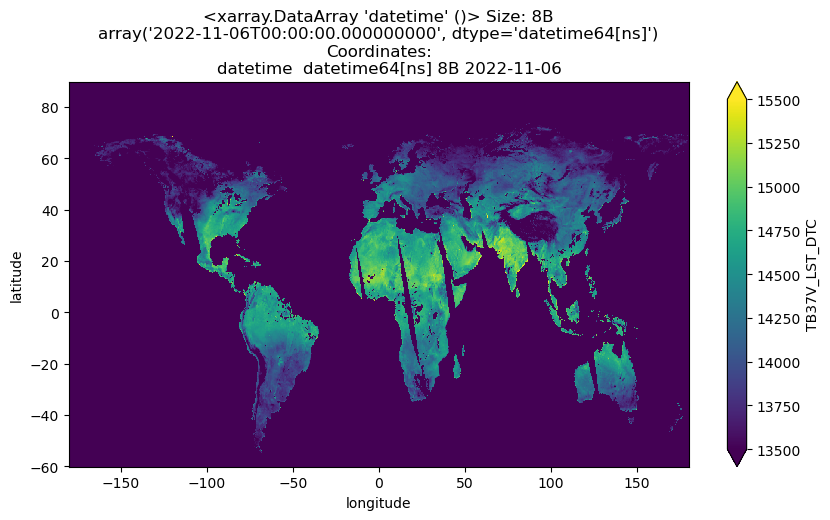

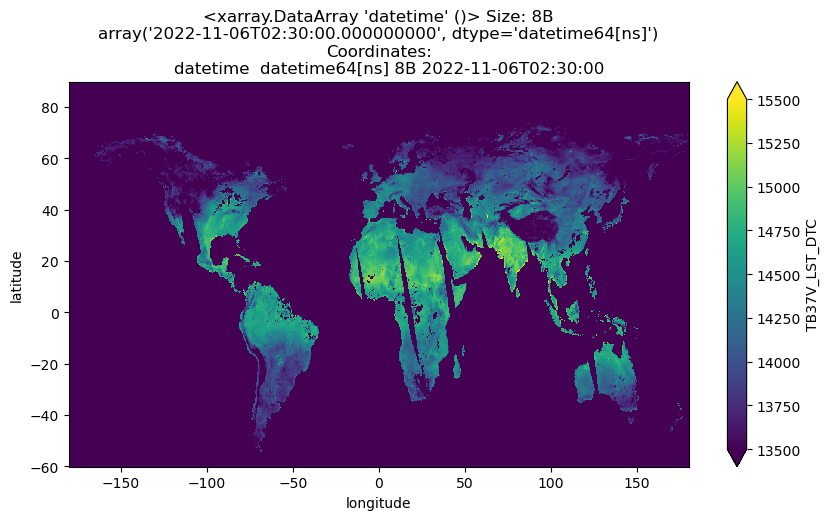

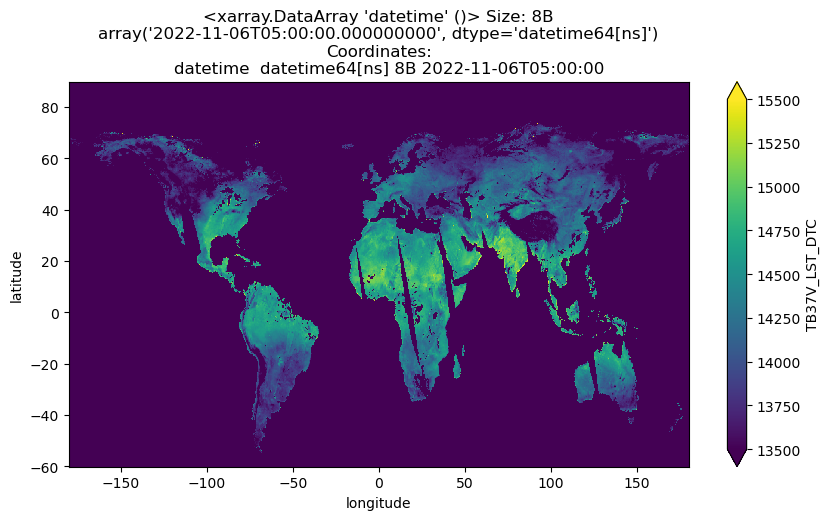

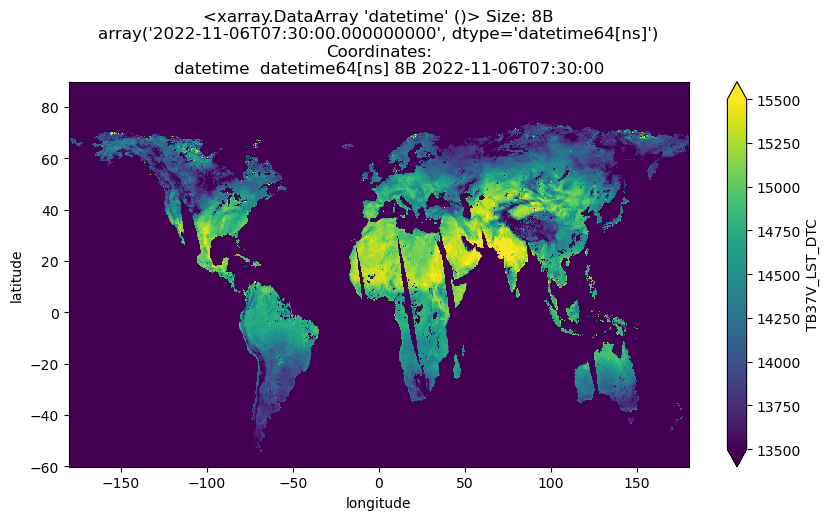

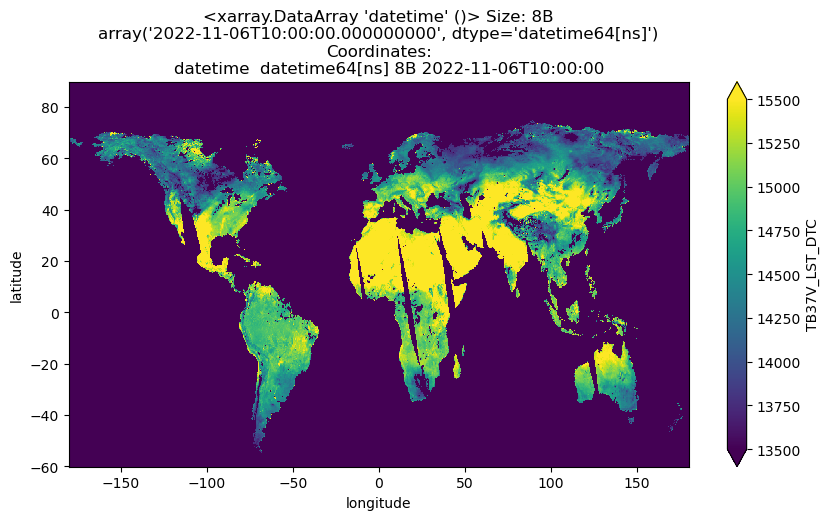

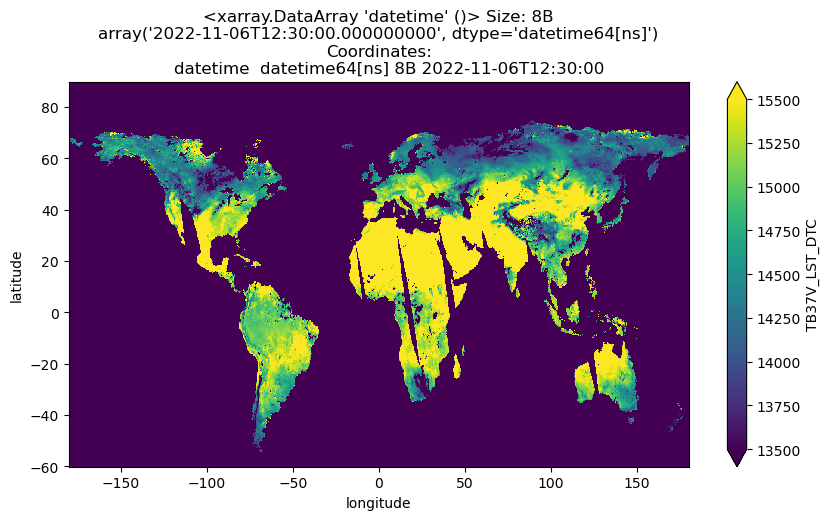

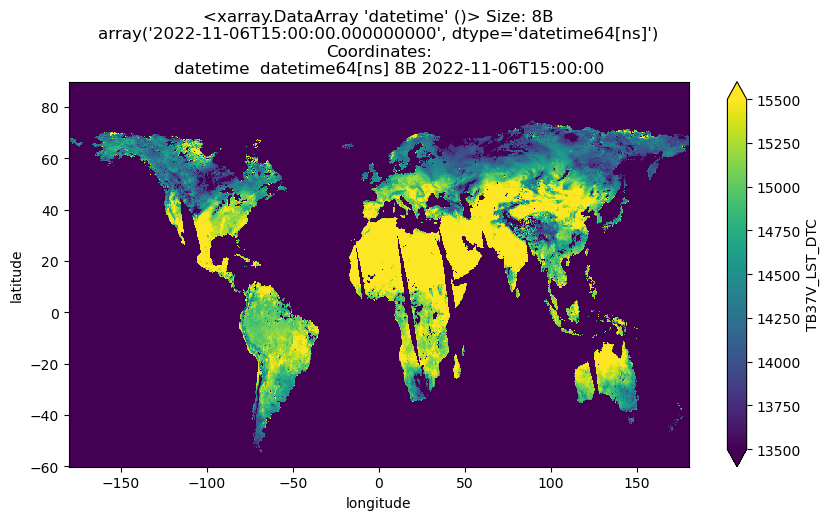

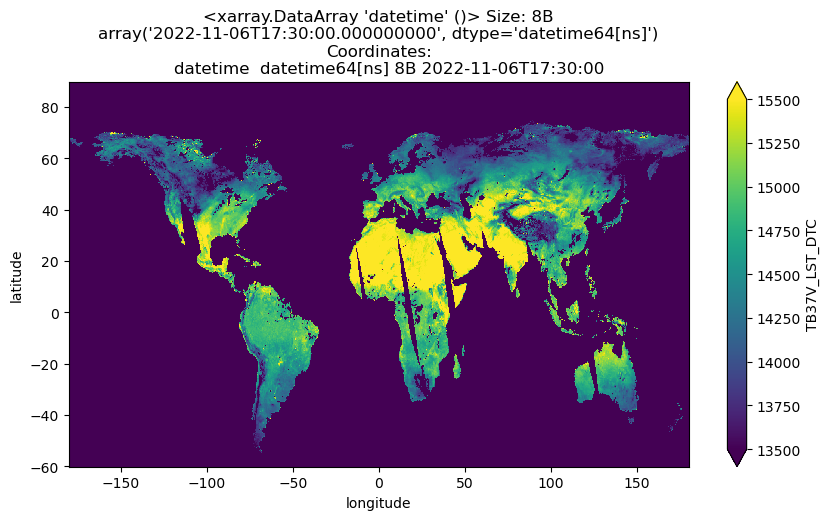

In [29]:
# Visualize the time coordinate of the MW LST data
for i in list(range(0, 80, 10)):
    dsMW['TB37V_LST_DTC'].isel(phony_dim_0=i).plot.pcolormesh("longitude", "latitude", vmin=13500, vmax=15500, figsize=(10,5))
    plt.title(dsMW['datetime'][i])
    plt.show()

In [41]:
np.max(latlon_pts_2km[:,:,0]), np.min(latlon_pts_2km[:,:,0]), np.max(latlon_pts_2km[:,:,1]), np.min(latlon_pts_2km[:,:,1])

(np.float64(-83.82099010261425),
 np.float64(-84.79545361222962),
 np.float64(34.2038764910845),
 np.float64(33.39037178734117))

In [42]:
def get_next_latlon_coord(n, above=True):
    """
    Returns the value rounded up or down to the nearest 0.25.

    Args:
    n (float): latitude or longitude coordinate
    above (boolean): True for round up, False for round down

    Returns:
    (float): The coordinate rounded to a multiple of 0.25
    """
    if above:
        return np.ceil(n*4)/4
    else:
        return np.floor(n*4)/4

In [43]:
np.where(dsMW['latitude'] == 38.5)[0][0]

np.int64(205)

In [44]:
np.where(dsMW['latitude'] == get_next_latlon_coord(np.min(latlon_pts_2km[:,:,1]), False))[0][0]

np.int64(226)

In [45]:
# Gets the indices of the MW LST coorinates completely surrounding the GOES coordinates
max_lon_index = np.where(dsMW['longitude'] == get_next_latlon_coord(np.max(latlon_pts_2km[:, :, 0]), True))[0][0]
min_lon_index = np.where(dsMW['longitude'] == get_next_latlon_coord(np.min(latlon_pts_2km[:, :, 0]), False))[0][0]
max_lat_index = np.where(dsMW['latitude'] == get_next_latlon_coord(np.max(latlon_pts_2km[:, :, 1]), True))[0][0]
min_lat_index = np.where(dsMW['latitude'] == get_next_latlon_coord(np.min(latlon_pts_2km[:, :, 1]), False))[0][0]

In [47]:
date_format = "%Y-%m-%dT%H:%M:%SZ"
time = '2023-01-05T01:00:00Z'
utc_dt = datetime.datetime.strptime(time, date_format)

In [48]:
def time_adjust(longitude, dt=utc_dt):
    """
    Adjusts a datetime in UTC to local time based on how far it is from
    the Prime Meridian and calculates an index 0-96 of which 15-minute
    timestamp it is closest to in the day.

    Args:
    longitude (float): Longitude value
    dt (datetime): Datetime with a time in UTC

    Returns:
    time_index (int): Integer 0-96 denoting which 15-minute timestamp the
                      adjusted time is closest to
    """
    local_dt = dt + datetime.timedelta(hours=(longitude/360)*24) # Adjusting for global local time
    time_index = local_dt.hour*4 + round(local_dt.minute/15+local_dt.second/3600) # Used in selection of datetime index from mw file (every 15 minutes)
    return time_index

In [49]:
# Find the time index of each longitude coordinate
func = np.vectorize(time_adjust)
time_indices = func(latlon_pts_2km[:, :, 0])
time_indices

array([[77, 77, 77, ..., 78, 78, 78],
       [77, 77, 77, ..., 78, 78, 78],
       [77, 77, 77, ..., 78, 78, 78],
       ...,
       [77, 77, 77, ..., 78, 78, 78],
       [77, 77, 77, ..., 78, 78, 78],
       [77, 77, 77, ..., 78, 78, 78]], shape=(45, 45))

In [50]:
# Clip the microwave file to the temporal and spatial indices
mw_clipped = dsMW['TB37V_LST_DTC'][np.min(time_indices):np.max(time_indices)+1, min_lon_index:max_lon_index+1, max_lat_index:min_lat_index+1]
mw_clipped

<xarray.DataArray 'TB37V_LST_DTC' (phony_dim_0: 2, phony_dim_1: 6,
                                   phony_dim_2: 5)> Size: 120B
[60 values with dtype=uint16]
Coordinates:
    datetime   (phony_dim_0) datetime64[ns] 16B 2022-11-06T19:15:00 2022-11-0...
    longitude  (phony_dim_1) float64 48B -85.0 -84.75 -84.5 -84.25 -84.0 -83.75
    latitude   (phony_dim_2) float64 40B 34.25 34.0 33.75 33.5 33.25
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2
Attributes:
    Gain:     50.0
    NoData:   0.0
    Offset:   0.0

In [51]:
# Divide by 50 to get physical MW LST values
mw_clipped[1].T.values/50

array([[296.38, 295.08, 294.56, 295.16, 298.16, 295.82],
       [296.38, 296.84, 296.44, 296.6 , 297.36, 296.56],
       [295.72, 297.44, 298.2 , 297.78, 296.86, 297.  ],
       [295.76, 296.36, 297.98, 296.6 , 296.78, 296.7 ],
       [295.54, 296.3 , 296.54, 296.68, 296.36, 295.82]])

In [59]:
y, x = np.meshgrid(mw_clipped['latitude'], mw_clipped['longitude'])
mw_latlons = np.stack((x,y)).T.reshape(-1,2)
mw_latlons

array([[-85.  ,  34.25],
       [-84.75,  34.25],
       [-84.5 ,  34.25],
       [-84.25,  34.25],
       [-84.  ,  34.25],
       [-83.75,  34.25],
       [-85.  ,  34.  ],
       [-84.75,  34.  ],
       [-84.5 ,  34.  ],
       [-84.25,  34.  ],
       [-84.  ,  34.  ],
       [-83.75,  34.  ],
       [-85.  ,  33.75],
       [-84.75,  33.75],
       [-84.5 ,  33.75],
       [-84.25,  33.75],
       [-84.  ,  33.75],
       [-83.75,  33.75],
       [-85.  ,  33.5 ],
       [-84.75,  33.5 ],
       [-84.5 ,  33.5 ],
       [-84.25,  33.5 ],
       [-84.  ,  33.5 ],
       [-83.75,  33.5 ],
       [-85.  ,  33.25],
       [-84.75,  33.25],
       [-84.5 ,  33.25],
       [-84.25,  33.25],
       [-84.  ,  33.25],
       [-83.75,  33.25]])

In [54]:
# For each time index in the mw_clipped array, interpolate the MW data to the GOES grid
interpolated_arrays = []
for arr in mw_clipped:
    mw_interpolated = interpolate.griddata(mw_latlons, arr.T.values.reshape(-1)/50, latlon_pts_2km, method='nearest')
    interpolated_arrays.append(mw_interpolated)
interpolated_array = np.stack(interpolated_arrays)

In [55]:
interpolated_array

array([[[295.4 , 295.4 , 295.4 , ..., 296.28, 296.28, 296.28],
        [295.4 , 295.4 , 295.4 , ..., 296.28, 296.28, 296.28],
        [295.4 , 295.4 , 295.4 , ..., 296.28, 296.28, 296.28],
        ...,
        [296.78, 296.78, 296.78, ..., 297.24, 297.16, 297.16],
        [296.78, 296.78, 296.78, ..., 297.24, 297.16, 297.16],
        [296.78, 296.78, 296.78, ..., 297.24, 297.16, 297.16]],

       [[295.08, 295.08, 295.08, ..., 295.82, 295.82, 295.82],
        [295.08, 295.08, 295.08, ..., 295.82, 295.82, 295.82],
        [295.08, 295.08, 295.08, ..., 295.82, 295.82, 295.82],
        ...,
        [296.36, 296.36, 296.36, ..., 296.78, 296.7 , 296.7 ],
        [296.36, 296.36, 296.36, ..., 296.78, 296.7 , 296.7 ],
        [296.36, 296.36, 296.36, ..., 296.78, 296.7 , 296.7 ]]],
      shape=(2, 45, 45))

In [56]:
interpolated_indices = time_indices-np.min(time_indices)
interpolated_indices

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(45, 45))

In [57]:
# Index the first dimension of the value array
mw_interpolated = interpolated_array[interpolated_indices, np.arange(45)[:, None], np.arange(45)]
mw_interpolated

array([[295.4 , 295.4 , 295.4 , ..., 295.82, 295.82, 295.82],
       [295.4 , 295.4 , 295.4 , ..., 295.82, 295.82, 295.82],
       [295.4 , 295.4 , 295.4 , ..., 295.82, 295.82, 295.82],
       ...,
       [296.78, 296.78, 296.78, ..., 296.78, 296.7 , 296.7 ],
       [296.78, 296.78, 296.78, ..., 296.78, 296.7 , 296.7 ],
       [296.78, 296.78, 296.78, ..., 296.78, 296.7 , 296.7 ]],
      shape=(45, 45))

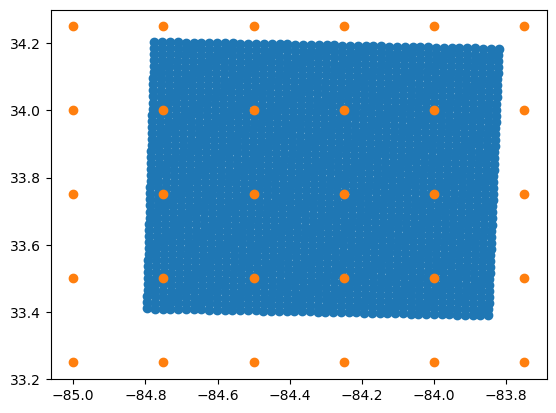

In [65]:
# Visualize the MW LST coordinates surrounding the GOES coordinates
plt.scatter(latlon_pts_2km[:,:,0], latlon_pts_2km[:,:,1])
plt.scatter(mw_latlons[:,0], mw_latlons[:,1])

In [66]:
# Set the MW LST variable
geotiff_dsG['microwave_LST'] = (('y','x'), mw_interpolated)

In [67]:
# Flip coordinates so latitude increases with index
geotiff_dsG = geotiff_dsG.reindex(y=geotiff_dsG.y[::-1])

In [68]:
geotiff_dsG

<xarray.Dataset> Size: 82kB
Dimensions:        (x: 45, y: 45)
Coordinates:
  * x              (x) float64 360B 7.05e+05 7.07e+05 ... 7.91e+05 7.93e+05
  * y              (y) float64 360B 3.699e+06 3.701e+06 ... 3.785e+06 3.787e+06
    spatial_ref    int64 8B 0
    datetime       <U20 80B '2022-05-20T03:00:20Z'
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB 268.7 268.5 268.4 ... 269.7 269.3 269.2
    microwave_LST  (y, x) float64 16kB 296.8 296.8 296.8 ... 295.8 295.8 295.8
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              0.0
    scale_factor:            1.0
    add_offset:              0.0

In [69]:
# Add metadata
geotiff_dsG['GOES_C13_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
geotiff_dsG['GOES_C13_LWIR'].attrs['units'] = 'K'
geotiff_dsG['GOES_C13_LWIR'].attrs['valid_min'] = 89.62
geotiff_dsG['GOES_C13_LWIR'].attrs['valid_max'] = 341.27
geotiff_dsG['GOES_C13_LWIR'].attrs['missing_value'] = np.nan
geotiff_dsG['GOES_C13_LWIR'].attrs['wavelength'] = '10.1-10.6 µm'

geotiff_dsG['GOES_C14_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
geotiff_dsG['GOES_C14_LWIR'].attrs['units'] = 'K'
geotiff_dsG['GOES_C14_LWIR'].attrs['valid_min'] = 96.19
geotiff_dsG['GOES_C14_LWIR'].attrs['valid_max'] = 341.28
geotiff_dsG['GOES_C14_LWIR'].attrs['missing_value'] = np.nan
geotiff_dsG['GOES_C14_LWIR'].attrs['wavelength'] = '10.8-11.6 µm'

geotiff_dsG['GOES_C15_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
geotiff_dsG['GOES_C15_LWIR'].attrs['units'] = 'K'
geotiff_dsG['GOES_C15_LWIR'].attrs['valid_min'] = 97.38
geotiff_dsG['GOES_C15_LWIR'].attrs['valid_max'] = 341.28
geotiff_dsG['GOES_C15_LWIR'].attrs['missing_value'] = np.nan
geotiff_dsG['GOES_C15_LWIR'].attrs['wavelength'] = '11.8-12.8 µm'

geotiff_dsG['GOES_C16_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
geotiff_dsG['GOES_C16_LWIR'].attrs['units'] = 'K'
geotiff_dsG['GOES_C16_LWIR'].attrs['valid_min'] = 92.7
geotiff_dsG['GOES_C16_LWIR'].attrs['valid_max'] = 318.26
geotiff_dsG['GOES_C16_LWIR'].attrs['missing_value'] = np.nan
geotiff_dsG['GOES_C16_LWIR'].attrs['wavelength'] = '13.0-13.6 µm'

geotiff_dsG['microwave_LST'].attrs['standard_name'] = 'surface_temperature'
geotiff_dsG['microwave_LST'].attrs['units'] = 'K'
geotiff_dsG['microwave_LST'].attrs['missing_value'] = np.nan
geotiff_dsG['microwave_LST'].attrs['wavelength'] = '0.81-0.83 cm'
geotiff_dsG['microwave_LST'].attrs['grid_mapping'] = 'spatial_ref'

In [70]:
geotiff_dsG['y'].attrs['standard_name'] = 'projection_y_coordinate'
geotiff_dsG['y'].attrs['long_name'] = 'UTM Northing'
geotiff_dsG['y'].attrs['units'] = 'm'

geotiff_dsG['x'].attrs['standard_name'] = 'projection_x_coordinate'
geotiff_dsG['x'].attrs['long_name'] = 'UTM Easting'
geotiff_dsG['x'].attrs['units'] = 'm'

geotiff_dsG['datetime'].attrs['long_name'] = 'datetime'
geotiff_dsG['datetime'].attrs['units'] = 'YYYY-mm-DDTHH:MM:SSZ'
geotiff_dsG['datetime'].attrs['calendar'] = 'utc'

In [71]:
if city in ['Seattle', 'San_Francisco', 'Los_Angeles', 'San_Diego', 'Phoenix', 'Las_Vegas', 'Salt_Lake_City']:
    geotiff_dsG.attrs['title'] = f'GOES-17/18 and microwave LST data for {city_str_dict[city]}'
else:
    geotiff_dsG.attrs['title'] = f'GOES-16 and microwave_LST data for {city_str_dict[city]}'
geotiff_dsG.attrs['institution'] = 'University of Maryland, College Park'
geotiff_dsG.attrs['source'] = 'Satellite observation'

In [72]:
del geotiff_dsG.attrs['TIFFTAG_XRESOLUTION']
del geotiff_dsG.attrs['TIFFTAG_YRESOLUTION']
del geotiff_dsG.attrs['TIFFTAG_RESOLUTIONUNIT']
del geotiff_dsG.attrs['_FillValue']

In [73]:
geotiff_dsG

<xarray.Dataset> Size: 82kB
Dimensions:        (x: 45, y: 45)
Coordinates:
  * x              (x) float64 360B 7.05e+05 7.07e+05 ... 7.91e+05 7.93e+05
  * y              (y) float64 360B 3.699e+06 3.701e+06 ... 3.785e+06 3.787e+06
    spatial_ref    int64 8B 0
    datetime       <U20 80B '2022-05-20T03:00:20Z'
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB 268.7 268.5 268.4 ... 269.7 269.3 269.2
    microwave_LST  (y, x) float64 16kB 296.8 296.8 296.8 ... 295.8 295.8 295.8
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          GOES-16 and microwave_LST data for Atlanta, Georgia, USA
    institution:    University of Maryland, College Park
    source:         Satellite observation

## Export and re-open

In [74]:
# Export the data as a test
geotiff_dsG.to_netcdf("/glade/derecho/scratch/jstarfeldt/GOES_sample.nc")

In [75]:
# Re-open the test file
xr.open_dataset("/glade/derecho/scratch/jstarfeldt/GOES_sample.nc")

<xarray.Dataset> Size: 82kB
Dimensions:        (y: 45, x: 45)
Coordinates:
  * x              (x) float64 360B 7.05e+05 7.07e+05 ... 7.91e+05 7.93e+05
  * y              (y) float64 360B 3.699e+06 3.701e+06 ... 3.785e+06 3.787e+06
    datetime       object 8B ...
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB ...
    microwave_LST  (y, x) float64 16kB ...
    spatial_ref    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          GOES-16 and microwave_LST data for Atlanta, Georgia, USA
    institution:    University of Maryland, College Park
    source:         Satellite observation

## Processing Functions

In [17]:
# Dictionary for full city name strings
city_str_dict = {
    'Atlanta': 'Atlanta, Georgia, USA',
    'Billings': 'Billings, Montana, USA',
    'Bogota': 'Bogota, Colombia',
    'Brasilia': 'Brasilia, Brazil',
    'Buenos_Aires': 'Buenos Aires, Argentina',
    'Cancun': 'Cancun, Mexico',
    'Caracas': 'Caracas, Venezuela',
    'Charlotte': 'Charlotte, North Carolina, USA',
    'Chicago': 'Chicago, Illinois, USA',
    'Dallas': 'Dallas, Texas, USA and Fort Worth, Texas, USA',
    'Denver': 'Denver, Colorado, USA',
    'Guadalajara': 'Guadalajara, Mexico',
    'Guatemala_City': 'Guatemala City, Guatemala',
    'Havana': 'Havana, Cuba',
    'Houston': 'Houston, Texas, USA',
    'Jacksonville': 'Jacksonville, Florida, USA',
    'La_Paz': 'La Paz, Bolivia',
    'Las_Vegas': 'Las Vegas, Nevada, USA',
    'Lima': 'Lima, Peru',
    'Los_Angeles': 'Los Angeles, California, USA',
    'Managua': 'Managua, Nicaragua',
    'Manaus': 'Manaus, Brazil',
    'Mexico_City': 'Mexico City, Mexico',
    'Miami': 'Miami, Florida, USA',
    'Minneapolis': 'Minneapolis, Minnesota, USA',
    'Monterrey': 'Monterrey, Mexico',
    'Montevideo': 'Montevideo, Uruguay',
    'Montreal': 'Montreal, Quebec, Canada',
    'New_Orleans': 'New Orleans, Louisiana, USA',
    'NYC': 'New York City, New York, USA',
    'Panama_City': 'Panama City, Panama',
    'Philadelphia': 'Philadelphia, Pennsylvania, USA',
    'Phoenix': 'Phoenix, Arizona, USA',
    'Punta_Arenas': 'Punta Arenas, Chile',
    'Quito': 'Quito, Ecuador',
    'Salt_Lake_City': 'Salt Lake City, Utah, USA',
    'San_Diego': 'San Diego, California, USA and Tijuana, Mexico',
    'San_Francisco': 'San Francisco, California, USA and San Jose, California, USA',
    'San_Jose': 'San Jose, Costa Rica',
    'San_Juan': 'San Juan, Puerto Rico',
    'Santiago': 'Santiago, Chile',
    'Santo_Domingo': 'Santo Domingo, Dominican Republic',
    'Sao_Paulo': 'Sao Paulo, Brazil',
    'Seattle': 'Seattle, Washington, USA',
    'St_Louis': 'St Louis, Missouri, USA',
    'Tegucigalpa': 'Tegucigalpa, Honduras',
    'Toronto': 'Toronto, Ontario, Canada',
    'DMV': 'Washington, DC, USA and Baltimore, Maryland, USA'
}

### Landsat

In [18]:
def sort_func_Landsat(s, form=int):
    """
    Gets the datetime from a Landsat/Sentinel-1 file string.
    Used to sort the list of files in a directory.

    Args:
    s (str): Full file location string of a Landsat/Sentinel-1 file

    Returns:
    (int): File datetime as an integer
    """
    if form == int:
        return int(s.split(f'{city}_')[1].split('.tif')[0])
    else:
        return str(s.split(f'{city}_')[1].split('.tif')[0])

In [19]:
def process_Landsat_Sentinel_tif(tif, time, coord_bounds=None):
    """
    Processing of individual Landsat/Sentinel-1 .tif files. Performs
    a variety of tasks on the data to make it easier to read and understand.

    Args:
        tif (str): Path where tif file is located
        time (str): Date and time of when the data was collected format YYYY-MM-DDThh:mm:ssZ.
        coord_bounds (tuple or list, optional): Coordinate bounds if you wish to filter the data by location. Order should be
                                        (longitude minimum, longitude maximum, latitude minimum, latitude maximum)

    Returns:
    geotiff_ds (xr.dataset): Fully processed file as an xarray dataset
    """
    #########################################################################################################
    # Open file and rename variables
    dsLS = rxr.open_rasterio(tif)[:,:3000,:3000] 
    dsLS = dsLS.reindex(y=dsLS.y[::-1]) # Invert y-axis so that values are increasing instead of decreasing with index
    geotiff_ds = dsLS.to_dataset('band')

    geotiff_ds = geotiff_ds.rename({1:'Landsat_blue_sfc_reflectance', 2:'Landsat_green_sfc_reflectance',
                                    3:'Landsat_red_sfc_reflectance', 4:'Landsat_NIR_sfc_reflectance',
                                    5:'Landsat_SWIR1_sfc_reflectance', 6:'Landsat_SWIR2_sfc_reflectance',
                                    7:'Landsat_LST', 8:'Landsat_cloud_mask', 9:'Sentinel1_VV', 10:'Sentinel1_VH', 11:'Sentinel1_HH',
                                    12:'Sentinel1_HV', 13:'Sentinel1_incidence_angle'})
    geotiff_ds = geotiff_ds.assign_coords({'datetime': time})
    del geotiff_ds.attrs['long_name']

    #########################################################################################################
    # Convert cloud mask integers to binary strings
    binary_vectorized = np.vectorize(to_binary_string)
    mask = binary_vectorized(geotiff_ds.Landsat_cloud_mask.values)
    geotiff_ds['Landsat_cloud_mask'].values = mask

    # Filter anomalous values from Sentinel-1 variables and set them to nan
    for variable in ['Sentinel1_VV', 'Sentinel1_VH', 'Sentinel1_HH', 'Sentinel1_HV']:
        geotiff_ds[variable].values = np.where(geotiff_ds[variable].values > 1, np.nan, geotiff_ds[variable].values)
    geotiff_ds['Sentinel1_incidence_angle'].values = np.where(geotiff_ds['Sentinel1_incidence_angle'].values < 0,
                                                      np.nan, geotiff_ds['Sentinel1_incidence_angle'].values)

    #########################################################################################################
    # Assign descriptive attributes for the cloud mask and a new coordinate for the file datetime
    if 'Landsat9' in tif:
        geotiff_ds.attrs['title'] = f'Landsat 9 and Sentinel-1 data for {city_str_dict[city]}'
    else:
        geotiff_ds.attrs['title'] = f'Landsat 8 and Sentinel-1 data for {city_str_dict[city]}'
    geotiff_ds.attrs['institution'] = 'University of Maryland, College Park'
    geotiff_ds.attrs['source'] = 'Satellite observation'

    geotiff_ds['y'].attrs['standard_name'] = 'projection_y_coordinate'
    geotiff_ds['y'].attrs['long_name'] = 'UTM Northing'
    geotiff_ds['y'].attrs['units'] = 'm'

    geotiff_ds['x'].attrs['standard_name'] = 'projection_x_coordinate'
    geotiff_ds['x'].attrs['long_name'] = 'UTM Easting'
    geotiff_ds['x'].attrs['units'] = 'm'

    geotiff_ds['datetime'].attrs['long_name'] = 'datetime'
    geotiff_ds['datetime'].attrs['units'] = 'YYYY-mm-DDTHH:MM:SSZ'
    geotiff_ds['datetime'].attrs['calendar'] = 'utc'

    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['long_name'] = 'L2_blue_surface_reflectance'
    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['units'] = '1'
    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['valid_max'] = 1
    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['missing_value'] = np.nan
    geotiff_ds['Landsat_blue_sfc_reflectance'].attrs['wavelength'] = '0.452-0.512 μm'

    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['long_name'] = 'L2_green_surface_reflectance'
    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['units'] = '1'
    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['valid_max'] = 1
    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['missing_value'] = np.nan
    geotiff_ds['Landsat_green_sfc_reflectance'].attrs['wavelength'] = '0.533-0.590 μm'

    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['long_name'] = 'L2_red_surface_reflectance'
    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['units'] = '1'
    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['valid_max'] = 1
    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['missing_value'] = np.nan
    geotiff_ds['Landsat_red_sfc_reflectance'].attrs['wavelength'] = '0.636-0.673 μm'

    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['long_name'] = 'L2_NIR_surface_reflectance'
    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['units'] = '1'
    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['valid_max'] = 1
    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['missing_value'] = np.nan
    geotiff_ds['Landsat_NIR_sfc_reflectance'].attrs['wavelength'] = '0.851-0.879 μm'

    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['long_name'] = 'L2_SWIR1_surface_reflectance'
    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['units'] = '1'
    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['valid_max'] = 1
    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['missing_value'] = np.nan
    geotiff_ds['Landsat_SWIR1_sfc_reflectance'].attrs['wavelength'] = '1.566-1.651 μm'

    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['standard_name'] = 'surface_bidirectional_reflectance'
    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['long_name'] = 'L2_SWIR2_surface_reflectance'
    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['units'] = '1'
    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['valid_max'] = 1
    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['missing_value'] = np.nan
    geotiff_ds['Landsat_SWIR2_sfc_reflectance'].attrs['wavelength'] = '2.107-2.294 μm'

    geotiff_ds['Landsat_LST'].attrs['standard_name'] = 'surface_temperature'
    geotiff_ds['Landsat_LST'].attrs['long_name'] = 'L2_band_10_land_surface_temperature'
    geotiff_ds['Landsat_LST'].attrs['units'] = 'K'
    geotiff_ds['Landsat_LST'].attrs['valid_min'] = 0
    geotiff_ds['Landsat_LST'].attrs['valid_max'] = 373
    geotiff_ds['Landsat_LST'].attrs['wavelength'] = '10.60-11.19 μm'
    geotiff_ds['Landsat_LST'].attrs['missing_value'] = np.nan

    geotiff_ds['Landsat_cloud_mask'].attrs['long_name'] = 'pixel_quality_mask'
    geotiff_ds['Landsat_cloud_mask'].attrs['bitmask_key'] = \
    "Bit 0: Fill\n\
    Bit 1: Dilated Cloud\n\
    Bit 2: Cirrus (high confidence)\n\
    Bit 3: Cloud\n\
    Bit 4: Cloud Shadow\n\
    Bit 5: Snow\n\
    Bit 6: Clear\n\t0: Cloud or Dilated Cloud bits are set\n\t1: Cloud and Dilated Cloud bits are not set\n\
    Bit 7: Water\n\
    Bits 8-9: Cloud Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High\n\
    Bits 10-11: Cloud Shadow Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High\n\
    Bits 12-13: Snow/Ice Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High\n\
    Bits 14-15: Cirrus Confidence\n\t0: None\n\t1: Low\n\t2: Medium\n\t3: High"

    geotiff_ds['Sentinel1_VV'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
    geotiff_ds['Sentinel1_VV'].attrs['long_name'] = 'SAR_VV_polarized_backscatter'
    geotiff_ds['Sentinel1_VV'].attrs['units'] = 'dB'
    geotiff_ds['Sentinel1_VV'].attrs['valid_max'] = 1
    geotiff_ds['Sentinel1_VV'].attrs['wavelength'] = '5.55 cm'
    geotiff_ds['Sentinel1_VV'].attrs['missing_value'] = np.nan

    geotiff_ds['Sentinel1_VH'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
    geotiff_ds['Sentinel1_VH'].attrs['long_name'] = 'SAR_VH_polarized_backscatter'
    geotiff_ds['Sentinel1_VH'].attrs['units'] = 'dB'
    geotiff_ds['Sentinel1_VH'].attrs['valid_max'] = 1
    geotiff_ds['Sentinel1_VH'].attrs['wavelength'] = '5.55 cm'
    geotiff_ds['Sentinel1_VH'].attrs['missing_value'] = np.nan

    geotiff_ds['Sentinel1_HH'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
    geotiff_ds['Sentinel1_HH'].attrs['long_name'] = 'SAR_HH_polarized_backscatter'
    geotiff_ds['Sentinel1_HH'].attrs['units'] = 'dB'
    geotiff_ds['Sentinel1_HH'].attrs['valid_max'] = 1
    geotiff_ds['Sentinel1_HH'].attrs['wavelength'] = '5.55 cm'
    geotiff_ds['Sentinel1_HH'].attrs['missing_value'] = np.nan

    geotiff_ds['Sentinel1_HV'].attrs['standard_name'] = 'surface_backwards_scattering_coefficient_of_radar_wave'
    geotiff_ds['Sentinel1_HV'].attrs['long_name'] = 'SAR_HV_polarized_backscatter'
    geotiff_ds['Sentinel1_HV'].attrs['units'] = 'dB'
    geotiff_ds['Sentinel1_HV'].attrs['valid_max'] = 1
    geotiff_ds['Sentinel1_HV'].attrs['wavelength'] = '5.55 cm'
    geotiff_ds['Sentinel1_HV'].attrs['missing_value'] = np.nan

    geotiff_ds['Sentinel1_incidence_angle'].attrs['standard_name'] = 'angle_of_incidence'
    geotiff_ds['Sentinel1_incidence_angle'].attrs['units'] = 'degree'
    geotiff_ds['Sentinel1_incidence_angle'].attrs['valid_min'] = 0
    geotiff_ds['Sentinel1_incidence_angle'].attrs['valid_max'] = 90
    geotiff_ds['Sentinel1_incidence_angle'].attrs['missing_value'] = np.nan

    #########################################################################################################
    # Optional filtering by lat/lon
    if coord_bounds:
        geotiff_ds = geotiff_ds.sel(longitude=slice(coord_bounds[0], coord_bounds[1])).sel(latitude=slice(coord_bounds[3], coord_bounds[2]))

    #########################################################################################################
    return geotiff_ds

In [20]:
# Test out the processing function
dt = datetime.datetime.fromtimestamp(times_Landsat[0]/1000, datetime.UTC).strftime('%Y-%m-%dT%H:%M:%SZ')
ds = process_Landsat_Sentinel_tif(Landsat_tif_list[0], dt)
ds

<xarray.Dataset> Size: 1GB
Dimensions:                        (y: 3000, x: 3000)
Coordinates:
  * x                              (x) float64 24kB 5.464e+05 ... 6.364e+05
  * y                              (y) float64 24kB 4.718e+05 ... 5.617e+05
    spatial_ref                    int64 8B 0
    datetime                       <U20 80B '2022-01-07T15:12:59Z'
Data variables: (12/13)
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_SWIR2_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Landsat_cloud_mask             (y, x) <U16 576MB '101010101000000' ... '1...
    Sentinel1_VV                   (y, x) float64 72MB -6.083 -8.685 ... -15.1
    Sentinel1_VH                   (y, x) float64 72MB -13.1 -13.79 ... -20.67
    Sentinel1_HH                   (y, x) float64 72MB nan nan nan ... nan nan
    Sentinel1_HV                   (y, x) float64 72MB nan nan nan ... nan nan
    Sentinel1_incidence_angle      (y, x) float64 72MB 39.18 39.18 ... 34.68
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          Landsat 8 and Sentinel-1 data for Bogota, Colombia
    institution:    University of Maryland, College Park
    source:         Satellite observation

In [24]:
# Runs processing function on all the geotif files for each city
for city in cities:
    processed_dir = '/glade/derecho/scratch/jstarfeldt/uhminicubes/hresgrid'
    times_Landsat = pd.read_csv(f'{tmp_dataset_root}/Landsat_times/Landsat_times_{city}.csv').value
    Landsat_root = f'{dataset_root}/{city}/Landsat'
    Landsat_tif_list = glob.glob(Landsat_root+'/Landsat8*.tif')
    Landsat_tif_list = sorted(Landsat_tif_list, key=sort_func_Landsat)

    for i in range(len(Landsat_tif_list)):
        dt_str = Landsat_tif_list[i].split('_')[-1].split('.')[0]
        fname = f'hresgrid_{city_ICAO_codes[city]}_{dt_str}.nc'
        dt = datetime.datetime.fromtimestamp(times_Landsat[i]/1000, datetime.UTC)
        dt_str = dt.strftime('%Y-%m-%dT%H:%M:%SZ')
        ds = process_Landsat_Sentinel_tif(Landsat_tif_list[i], dt_str)
        ds.to_netcdf(f'{processed_dir}/{str(dt.year)}/{stringify(dt.month)}/{city_ICAO_codes[city]}/{fname}')

### GOES

In [102]:
"""
Processing of individual .tif files.

Performs a variety of tasks on the data to make it more easy to read and understand.

Attributes:
    tif (str): Path where tif file is located.
    time (str): Date and time of when the data was collected format YYYY-MM-DDThh:mm:ssZ.
    latlon_pts (float array): (45,45,2) Array of (longitude, latitude) points at each point on the utm grid.
    local_timezone (pytz timezone): Local timezone of the area you are creating data for
    coord_bounds (tuple or list, optional): Coordinate bounds if you wish to filter the data by location. Order should be
                                    (longitude minimum, longitude maximum, latitude minimum, latitude maximum).
"""
def process_GOES_tif(tif, time, latlon_pts, coord_bounds=None):
    #########################################################################################################
    # Open file and rename variables
    dsG = rxr.open_rasterio(tif)
    geotiff_ds = dsG.to_dataset('band')
    geotiff_ds = geotiff_ds.rename({1:'GOES_C13_LWIR', 2:'GOES_C14_LWIR',
                                      3:'GOES_C15_LWIR', 4:'GOES_C16_LWIR'})
    geotiff_ds = geotiff_ds.assign_coords({'datetime':time})

    #########################################################################################################
    # Process microwave data
    """
    Returns the value rounded up or down to the nearest 0.25.

    Attributes:
        n (float): latitude or longitude coordinate.
        above (boolean): True for round up, False for round down.
    """
    def get_next_latlon_coord(n, above=True):
        if above:
            return np.ceil(n*4)/4
        else:
            return np.floor(n*4)/4


    # Calculate adjusted datetimes for the left and right edges of the image.
    # If the datetimes are across two days, values from two mw LST files need to be used.
    min_longitude = np.min(latlon_pts[:,:,0])
    max_longitude = np.max(latlon_pts[:,:,0])

    date_format = "%Y-%m-%dT%H:%M:%SZ"
    utc_dt = datetime.datetime.strptime(time, date_format)
    local_dt1 = utc_dt + datetime.timedelta(hours=(min_longitude/360)*24)
    date_str1 = f'{local_dt1.year}{stringify(local_dt1.month)}{stringify(local_dt1.day)}'
    local_dt2 = utc_dt + datetime.timedelta(hours=(max_longitude/360)*24)
    date_str2 = f'{local_dt2.year}{stringify(local_dt2.month)}{stringify(local_dt2.day)}'


    """
    Adjusts a datetime in UTC to local time based on how far it is from the Prime Meridian and
    calculates an index 0-96 of which 15-minute interval the time is in a day.

    Attributes:
        longitude (float): Longitude value.
        dt (python datetime object): Datetime with a time in UTC.
    """
    def time_adjust(longitude, dt=utc_dt):
        local_dt = dt + datetime.timedelta(hours=(longitude/360)*24) # Adjusting for global local time
        time_index = local_dt.hour*4 + round(local_dt.minute/15+local_dt.second/3600) # Used in selection of datetime index from mw file (every 15 minutes)
        return time_index

    func = np.vectorize(time_adjust)
    time_indices = func(latlon_pts[:,:,0])

    # Accounting for rounding of values to timestep of following day
    if np.sum(time_indices<96) < 2025: 
        local_dt2 = local_dt2 + datetime.timedelta(days=1)
        date_str2 = f'{local_dt2.year}{stringify(local_dt2.month)}{stringify(local_dt2.day)}'

    # Accounting for files we do not have currently
    if date_str1 == '20211231' or date_str2 == '20211231' or date_str1 == '20220322' or date_str2 == '20220322':
        print('date string identifited')
        return

    if date_str1 != date_str2: # When data spans two days (two different files)
        dsMW = xr.open_dataset(f'{tmp_dataset_root}/mw_data/MW_LST_DTC_{date_str1}_x1y.h5', engine='h5netcdf')
        dsMW = dsMW.assign_coords(
            datetime=("phony_dim_0", pd.date_range(start=date_str1, periods=96, freq="15min")),
            longitude=("phony_dim_1", np.arange(-180,180,0.25)),
            latitude=("phony_dim_2", np.arange(-60,90,0.25)[::-1]))
 
        dsMW2 = xr.open_dataset(f'{tmp_dataset_root}/mw_data/MW_LST_DTC_{date_str2}_x1y.h5', engine='h5netcdf')
        dsMW2 = dsMW.assign_coords(
            datetime=("phony_dim_0", pd.date_range(start=date_str2, periods=96, freq="15min")),
            longitude=("phony_dim_1", np.arange(-180,180,0.25)),
            latitude=("phony_dim_2", np.arange(-60,90,0.25)[::-1]))    

        dsMW = xr.concat([dsMW.to_dataarray()[0], dsMW2.to_dataarray()[0]], dim='phony_dim_0') # Concatenate arrays to be continuous
        time_indices = np.where(time_indices>90, time_indices, time_indices+96) # Adjust time indices to be in continuous order
    else:
        dsMW = xr.open_dataset(f'{tmp_dataset_root}/mw_data/MW_LST_DTC_{date_str1}_x1y.h5', engine='h5netcdf')
        dsMW = dsMW.assign_coords(
            datetime=("phony_dim_0", pd.date_range(start=date_str1, periods=96, freq="15min")),
            longitude=("phony_dim_1", np.arange(-180,180,0.25)),
            latitude=("phony_dim_2", np.arange(-60,90,0.25)[::-1]))


    max_lon_index = np.where(dsMW['longitude'] == get_next_latlon_coord(np.max(latlon_pts[:,:,0]), True))[0][0]
    min_lon_index = np.where(dsMW['longitude'] == get_next_latlon_coord(np.min(latlon_pts[:,:,0]), False))[0][0]
    max_lat_index = np.where(dsMW['latitude'] == get_next_latlon_coord(np.max(latlon_pts[:,:,1]), True))[0][0]
    min_lat_index = np.where(dsMW['latitude'] == get_next_latlon_coord(np.min(latlon_pts[:,:,1]), False))[0][0]

    # Create microwave array for specific area
    # Remember: latitude decreases with index
    if date_str1 != date_str2: # Concatenation removes TB37V_LST_DTC variable
        mw_clipped = dsMW[np.min(time_indices):np.max(time_indices)+1,min_lon_index:max_lon_index+1,max_lat_index:min_lat_index+1]
        dsMW.close()
        dsMW2.close()
    else:
        mw_clipped = dsMW['TB37V_LST_DTC'][np.min(time_indices):np.max(time_indices)+1,min_lon_index:max_lon_index+1,max_lat_index:min_lat_index+1]
        dsMW.close()

    y, x = np.meshgrid(mw_clipped['latitude'], mw_clipped['longitude'])
    mw_latlons = np.stack((x,y)).T.reshape(-1,2)

    interpolated_arrays = []
    for arr in mw_clipped:
        mw_interpolated = interpolate.griddata(mw_latlons, arr.T.values.reshape(-1)/50, latlon_pts, method='nearest')
        interpolated_arrays.append(mw_interpolated)
    interpolated_array = np.stack(interpolated_arrays) # Interpolated microwave values from each time index n of shape (n,45,45)
    interpolated_indices = time_indices-np.min(time_indices) # Array of shape (45,45) that select time indices from the value array
    
    # Index the first dimension of the value array
    mw_interpolated = interpolated_array[interpolated_indices, np.arange(45)[:, None], np.arange(45)]

    geotiff_ds['microwave_LST'] = (('y','x'), mw_interpolated)

    # Flip coordinates so latitude increases with index
    geotiff_ds = geotiff_ds.reindex(y=geotiff_ds.y[::-1])

    # Add file metadata
    if city in ['Seattle', 'San_Francisco', 'Los_Angeles', 'San_Diego', 'Phoenix', 'Las_Vegas', 'Salt_Lake_City']:
        geotiff_ds.attrs['title'] = f'GOES-17/18 and microwave LST data for {city_str_dict[city]}'
    else:
        geotiff_ds.attrs['title'] = f'GOES-16 and microwave_LST data for {city_str_dict[city]}'
    geotiff_ds.attrs['institution'] = 'University of Maryland, College Park'
    geotiff_ds.attrs['source'] = 'Satellite observation'

    # Delete unnecessary tags
    del geotiff_ds.attrs['TIFFTAG_XRESOLUTION']
    del geotiff_ds.attrs['TIFFTAG_YRESOLUTION']
    del geotiff_ds.attrs['TIFFTAG_RESOLUTIONUNIT']
    del geotiff_ds.attrs['_FillValue']
        
    # Add variable metadata
    geotiff_ds['y'].attrs['standard_name'] = 'projection_y_coordinate'
    geotiff_ds['y'].attrs['long_name'] = 'UTM Northing'
    geotiff_ds['y'].attrs['units'] = 'm'
    
    geotiff_ds['x'].attrs['standard_name'] = 'projection_x_coordinate'
    geotiff_ds['x'].attrs['long_name'] = 'UTM Easting'
    geotiff_ds['x'].attrs['units'] = 'm'

    geotiff_ds['datetime'].attrs['long_name'] = 'datetime'
    geotiff_ds['datetime'].attrs['units'] = 'YYYY-mm-DDTHH:MM:SSZ'
    geotiff_ds['datetime'].attrs['calendar'] = 'utc'
    
    geotiff_ds['GOES_C13_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
    geotiff_ds['GOES_C13_LWIR'].attrs['units'] = 'K'
    geotiff_ds['GOES_C13_LWIR'].attrs['valid_min'] = 89.62
    geotiff_ds['GOES_C13_LWIR'].attrs['valid_max'] = 341.27
    geotiff_ds['GOES_C13_LWIR'].attrs['missing_value'] = np.nan
    geotiff_ds['GOES_C13_LWIR'].attrs['wavelength'] = '10.1-10.6 µm'
    
    geotiff_ds['GOES_C14_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
    geotiff_ds['GOES_C14_LWIR'].attrs['units'] = 'K'
    geotiff_ds['GOES_C14_LWIR'].attrs['valid_min'] = 96.19
    geotiff_ds['GOES_C14_LWIR'].attrs['valid_max'] = 341.28
    geotiff_ds['GOES_C14_LWIR'].attrs['missing_value'] = np.nan
    geotiff_ds['GOES_C14_LWIR'].attrs['wavelength'] = '10.8-11.6 µm'
    
    geotiff_ds['GOES_C15_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
    geotiff_ds['GOES_C15_LWIR'].attrs['units'] = 'K'
    geotiff_ds['GOES_C15_LWIR'].attrs['valid_min'] = 97.38
    geotiff_ds['GOES_C15_LWIR'].attrs['valid_max'] = 341.28
    geotiff_ds['GOES_C15_LWIR'].attrs['missing_value'] = np.nan
    geotiff_ds['GOES_C15_LWIR'].attrs['wavelength'] = '11.8-12.8 µm'
    
    geotiff_ds['GOES_C16_LWIR'].attrs['standard_name'] = 'toa_brightness_temperature'
    geotiff_ds['GOES_C16_LWIR'].attrs['units'] = 'K'
    geotiff_ds['GOES_C16_LWIR'].attrs['valid_min'] = 92.7
    geotiff_ds['GOES_C16_LWIR'].attrs['valid_max'] = 318.26
    geotiff_ds['GOES_C16_LWIR'].attrs['missing_value'] = np.nan
    geotiff_ds['GOES_C16_LWIR'].attrs['wavelength'] = '13.0-13.6 µm'
    
    geotiff_ds['microwave_LST'].attrs['standard_name'] = 'surface_temperature'
    geotiff_ds['microwave_LST'].attrs['units'] = 'K'
    geotiff_ds['microwave_LST'].attrs['missing_value'] = np.nan
    geotiff_ds['microwave_LST'].attrs['wavelength'] = '0.81-0.83 cm'
    geotiff_ds['microwave_LST'].attrs['grid_mapping'] = 'spatial_ref'

    #########################################################################################################
    # Optional filtering by lat/lon
    if coord_bounds:
        geotiff_ds = geotiff_ds.sel(longitude=slice(coord_bounds[0], coord_bounds[1])).sel(latitude=slice(coord_bounds[3], coord_bounds[2]))

    #########################################################################################################
    return geotiff_ds

In [103]:
# Test out the processing function
dt = datetime.datetime.fromtimestamp(times_GOES[500]/1000, datetime.UTC).strftime('%Y-%m-%dT%H:%M:%SZ')
ds = process_GOES_tif(GOES_tif_list[500], dt, latlon_pts_2km)
ds

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_10745/2427905561.py:105: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  dsMW = xr.open_dataset(f'/glade/derecho/scratch/jstarfeldt/urban_heat_dataset/mw_data/MW_LST_DTC_{date_str1}_x1y.h5', engine='h5netcdf')


<xarray.Dataset> Size: 82kB
Dimensions:        (x: 45, y: 45)
Coordinates:
  * x              (x) float64 360B 2.93e+05 2.95e+05 ... 3.79e+05 3.81e+05
  * y              (y) float64 360B 4.283e+06 4.285e+06 ... 4.369e+06 4.371e+06
    spatial_ref    int64 8B 0
    datetime       <U20 80B '2022-01-04T11:20:20Z'
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB ...
    microwave_LST  (y, x) float64 16kB 266.6 268.5 268.5 ... 267.0 267.0 267.0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          GOES-16 and microwave_LST data for Washington, DC, USA an...
    institution:    University of Maryland, College Park
    source:         Satellite observation